<div style="border: 2px solid #c0a1a8; padding: 20px; width: 800px; border-radius: 10px; background: #f5faff; text-align:left; margin: 50px auto;">
    <h3 style="color:#2a7ae2; margin-bottom: 15px;">Project HDDA</h3>
    <p style="font-size:20px; color:#333; margin:5px 0;"><strong>Charlotte Chepngeno Sigei</strong></p>
    <p style="font-size:20px; color:#333; margin:5px 0;"><strong>SANE Fatoumata</strong></p>
    <p style="font-size:20px; color:#333; margin:5px 0;"><strong>OKERE Rafiatou</strong></p>
    <p style="font-size:20px; color:#333; margin:5px 0;"><strong>Ansoumane Conde</strong></p>
</div>


<h1 style="color:#2a7ae2; margin-bottom: 15px;"> Part 1 : Theory: CA, MCA and SVD</h1>

---

## 1. SVD – Singular Value Decomposition

###  Summary (key points)

* SVD decomposes any matrix (X) into three orthogonal matrices.
* It is the mathematical foundation of **PCA**, **PCR**, **Ridge regression**, etc.
* It provides an **optimal low-rank approximation**.

---

###  Definition

The **Singular Value Decomposition (SVD)** is a fundamental matrix decomposition widely used in statistics and machine learning.

For any matrix (X \in \mathbb{R}^{N \times p}):

```
X = U D V^T
```

where:

* `U`: left singular vectors (orthonormal)
* `D`: diagonal matrix of singular values
* `V`: right singular vectors (orthonormal)

---

###  Important properties

* Columns of `V` are eigenvectors of (X^T X)
* Columns of `U` are eigenvectors of (X X^T)
* Eigenvalues are (d_j^2)

---

###  Rank-k approximation

The best rank-`k` approximation is:

```
X_k = U_k D_k V_k^T
```

It minimizes the squared reconstruction error.

---

###  SVD and regression

For the linear model:

```
y = Xβ + ε
```

The ordinary least squares solution is:

```
β̂ = V D^{-1} U^T y
```

---

## 2. PCA – Principal Component Analysis

###  Summary (key points)

* PCA is an **unsupervised** dimension reduction method.
* It finds directions of **maximum variance**.
* Principal components are **uncorrelated** by construction.

---

###  Definition

PCA transforms correlated variables into new uncorrelated variables called **principal components**.

The analysis is performed on a **centered** data matrix `X`.

---

###  Mathematical formulation

The first principal component solves:

```
max ||v|| = 1  Var(Xv)
```

which leads to the eigenvalue problem:

```
(X^T X) v = λ v
```

---

###  Link with SVD

If:

```
X = U D V^T
```

then:

* Principal directions: columns of `V`
* Scores: `Z = U D`
* Variance explained: `d_k^2 / (N - 1)`

---

###  Important remarks

* PCA depends on variable scaling → **standardization is often required**
* High variance does not necessarily mean high predictive power

---

## 3. CA – Correspondence Analysis

###  Summary (key points)

* CA analyzes **two categorical variables**.
* It is based on the **chi-square distance**.
* It provides a joint visualization of rows and columns.

---

###  Data structure

A contingency table `N`.

Define:

```
P = N / n
```

where `n` is the total count.

---

###  Method

* Row and column profiles
* Standardized residual matrix:

```
Z = (P - r c^T) / sqrt(r c^T)
```

* Singular Value Decomposition:

```
Z = U D V^T
```

---

###  Interpretation

* Points close together → similar profiles
* A row point close to a column point → strong association

---

## 4. MCA – Multiple Correspondence Analysis

###  Summary (key points)

* MCA generalizes CA to **more than two categorical variables**.
* It is the categorical counterpart of PCA.
* Widely used in **survey and questionnaire analysis**.

---

###  Data structure

* Complete disjunctive (indicator) table `Z`
* Burt matrix:

```
B = Z^T Z
```

---

###  Method

* Perform CA on `Z` or `B`
* Extract factorial axes and coordinates

---

###  Reading MCA plots

* Individuals close together → similar profiles
* Categories close together → tend to occur together

---

## 5. Comparison of methods

| Method | Data type      | Distance   | Objective         |
| ------ | -------------- | ---------- | ----------------- |
| SVD    | Any matrix     | –          | Decomposition     |
| PCA    | Quantitative   | Euclidean  | Maximize variance |
| CA     | 2 categorical  | Chi-square | Associations      |
| MCA    | 3+ categorical | Chi-square | Profiles          |

---

##  Conclusion for the project

* **SVD**: theoretical foundation
* **PCA**: analysis of AIMS quantitative variables
* **CA / MCA**: use if categorical variables are involved


<h1 style="color:#2a7ae2; margin-bottom: 15px;"> Part II-1 : PCA</h1>

In [2]:
#!pip install prince 


# Before starting the analysis, we clean the dataset before preprocessing.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.formula.api import ols
import numpy as np
from prince import PCA

In [3]:
dataset = pd.read_csv("HDDAdataexam26.csv", sep=';', decimal=',')


In [4]:
dataset

,Phone,SocialNetworks,Happiness,Walk,InstagramRatio
0,360,360.0,6,12.0,1.267717
1,180,130.0,6,3.0,0.542083
2,250,120.0,7,8.0,0.750000
3,120,80.0,8,7.0,1.796407
4,190,1.0,3,10.0,0.846561
...,...,...,...,...,...
364,45,30.0,9,4.0,1.085873
365,200,100.0,7,4.0,1.072464
366,180,120.0,10,6.0,0.990868
367,1,30.0,8,6.0,0.894569


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369 entries, 0 to 368
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Phone           369 non-null    int64  
 1   SocialNetworks  369 non-null    float64
 2   Happiness       369 non-null    int64  
 3   Walk            369 non-null    float64
 4   InstagramRatio  369 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 14.5 KB


In [6]:
#See the different types of each variable
dataset.dtypes

Phone               int64
SocialNetworks    float64
Happiness           int64
Walk              float64
InstagramRatio    float64
dtype: object

##### Our dataset contains five variables: Phone and Happiness are integers, while SocialNetwork, Walk, and InstagramRatio are floats.

In [7]:
# dimension of or dataset



dataset.shape


(369, 5)

In [ ]:
#Looking for missing values
print(dataset.isnull().sum())

Phone             0
SocialNetworks    0
Happiness         0
Walk              0
InstagramRatio    0
dtype: int64


In [8]:
dataset.head()

,Phone,SocialNetworks,Happiness,Walk,InstagramRatio
0,360,360.0,6,12.0,1.267717
1,180,130.0,6,3.0,0.542083
2,250,120.0,7,8.0,0.750000
3,120,80.0,8,7.0,1.796407
4,190,1.0,3,10.0,0.846561


In [9]:
dataset.dtypes

Phone               int64
SocialNetworks    float64
Happiness           int64
Walk              float64
InstagramRatio    float64
dtype: object

In [10]:
dataset.isnull().sum()

Phone             0
SocialNetworks    0
Happiness         0
Walk              0
InstagramRatio    0
dtype: int64

#### We observe that there are no missing values in the dataset.

In [11]:
print(dataset.duplicated().sum())


1


##### We have 1 duplicate in our dataset

In [12]:
print(dataset[dataset.duplicated()])
#verification of our duplicate

     Phone  SocialNetworks  Happiness  Walk  InstagramRatio
166    120            50.0          7   2.0             0.0


In [13]:
dataset=dataset.drop_duplicates()


#### An then, we remove use this methode  "drop_duplicates()"

In [14]:
dataset

,Phone,SocialNetworks,Happiness,Walk,InstagramRatio
0,360,360.0,6,12.0,1.267717
1,180,130.0,6,3.0,0.542083
2,250,120.0,7,8.0,0.750000
3,120,80.0,8,7.0,1.796407
4,190,1.0,3,10.0,0.846561
...,...,...,...,...,...
364,45,30.0,9,4.0,1.085873
365,200,100.0,7,4.0,1.072464
366,180,120.0,10,6.0,0.990868
367,1,30.0,8,6.0,0.894569


In [15]:
print(dataset.duplicated().sum())

0


In [16]:
print("\n--- Statistics describes ---")
print(dataset.describe())


--- Statistics describes ---
             Phone  SocialNetworks   Happiness        Walk  InstagramRatio
count   368.000000      368.000000  368.000000  368.000000      368.000000
mean    125.888587       80.407609    7.461957    6.221114        1.178748
std     132.824713      104.748282    1.623623    3.234993        3.200836
min       1.000000        1.000000    1.000000    1.000000        0.000000
25%       9.750000       30.000000    7.000000    4.000000        0.579938
50%     120.000000       60.000000    8.000000    5.000000        0.962097
75%     180.000000      120.000000    8.000000    8.125000        1.245651
max    1440.000000     1440.000000   10.000000   20.000000       51.333333


##### Now, our dataset is clean and ready for the next step.

#### We use the correlation matrix to examine the relationships between variables and to better understand the dataset.

                   Phone  SocialNetworks  Happiness      Walk  InstagramRatio
Phone           1.000000        0.719449  -0.114472 -0.073922       -0.021818
SocialNetworks  0.719449        1.000000  -0.030229 -0.054495        0.018314
Happiness      -0.114472       -0.030229   1.000000  0.068935       -0.106751
Walk           -0.073922       -0.054495   0.068935  1.000000       -0.068680
InstagramRatio -0.021818        0.018314  -0.106751 -0.068680        1.000000


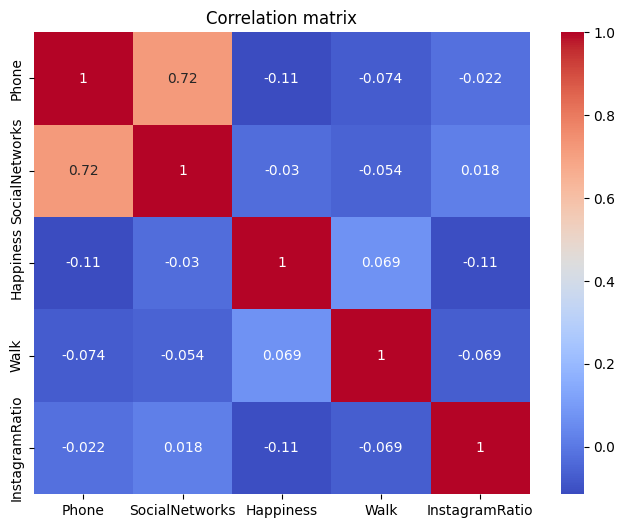

In [17]:
# 3) Matrix of correlation
corr_matrix = dataset.corr()
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

### Interpratation

The correlation matrix highlights the linear relationships between the variables in the dataset.

Phone and SocialNetworks show a strong positive correlation (0.72).
This indicates that increased phone usage is strongly associated with higher use of social networks.

Happiness has weak correlations with all other variables.

With Phone (−0.11) and InstagramRatio (−0.11), the correlations are slightly negative, suggesting a very weak inverse relationship.

With Walk (0.07), the correlation is weakly positive, indicating that walking activity has a minimal positive association with happiness.

Walk is weakly correlated with all other variables, implying that physical activity is largely independent of phone and social media usage in this dataset.

InstagramRatio shows very weak correlations with all variables, including SocialNetworks (0.02) and Phone (−0.02), suggesting no meaningful linear relationship.





#### Conclusion
Apart from the strong relationship between Phone usage and SocialNetworks, all other correlations are weak, indicating limited linear dependence among the remaining variables. This suggests that most variables contribute independent information, which is beneficial for further analysis or modeling.

In [18]:
# 4) Standardisation
scaler = StandardScaler()
data_scaled = scaler.fit_transform(dataset)

In [19]:
# Convert to dataframe
data_scaled_df = pd.DataFrame(data_scaled, columns=dataset.columns)


In [20]:
pca = PCA(n_components=5)
pca_result = pca.fit_transform(dataset)

In [21]:
#Affichage des valeurs propres et variance expliquée
print("\n=== VALEURS PROPRES ET VARIANCE EXPLIQUÉE ===")
eigenvalues = pca.eigenvalues_
# Calculer la variance expliquée manuellement
total_variance = sum(eigenvalues)
variance_ratio = [eigen / total_variance for eigen in eigenvalues]

for i, (eigen, var) in enumerate(zip(eigenvalues, variance_ratio)):
    print(f"PC{i+1}: Valeur propre = {eigen:.4f}, Variance expliquée = {var*100:.2f}%")

print(f"\nVariance cumulée PC1+PC2: {sum(variance_ratio[:2])*100:.2f}%")



=== VALEURS PROPRES ET VARIANCE EXPLIQUÉE ===
PC1: Valeur propre = 1.7478, Variance expliquée = 34.96%
PC2: Valeur propre = 1.1460, Variance expliquée = 22.92%
PC3: Valeur propre = 0.9403, Variance expliquée = 18.81%
PC4: Valeur propre = 0.8925, Variance expliquée = 17.85%
PC5: Valeur propre = 0.2735, Variance expliquée = 5.47%

Variance cumulée PC1+PC2: 57.88%


The Principal Component Analysis (PCA) shows that PC1 has an eigenvalue of 1.7478 and explains 34.96% of the total variance. This means that PC1 is the most important component in the data.

PC2 explains 22.92% of the variance, with an eigenvalue of 1.1460. Together, PC1 and PC2 explain 57.88% of the total variance, which indicates that most of the information in the data is captured by these two components.

PC3 and PC4 explain 18.81% and 17.85% of the variance respectively, but their eigenvalues are below 1, so they contribute less compared to the first two components.

PC5 explains only 5.47% of the variance and is not very informative.

Conclusion:
Using the first two principal components is reasonable because they summarize more than half of the total variability in the data.

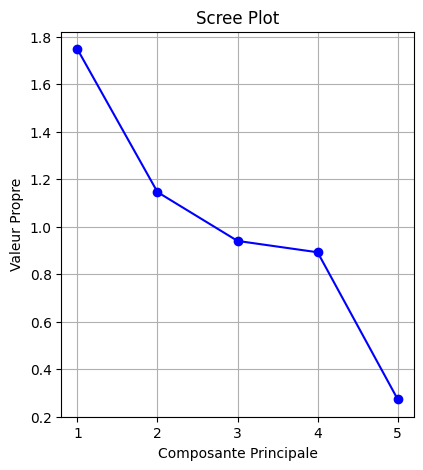

In [22]:
# Visualisation : Graphique des valeurs propres (Scree plot)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'bo-')
plt.xlabel('Composante Principale')
plt.ylabel('Valeur Propre')
plt.title('Scree Plot')
plt.grid(True)

**Interpretation : **
 SCREE PLOT ANALYSIS

**1. KAISER CRITERION (Eigenvalue > 1):**
   
   ✓ PC1 = 1.75 > 1  → KEEP
   ✓ PC2 = 1.15 > 1  → KEEP
   ✓ PC3 = 0.94 < 1  → DROP
   ✓ PC4 = 0.89 < 1  → DROP
   ✓ PC5 = 0.27 < 1  → DROP
   
   → Keep 2 components according to Kaiser rule

**2. ELBOW METHOD:**
   
   Look for where the curve flattens:
   - PC1 → PC2: Large drop (-0.60)
   - PC2 → PC3: Moderate drop (-0.21)
   - PC3 → PC4: Small drop (-0.05)
   - PC4 → PC5: Large drop (-0.62)
   
   → Elbow is around PC2-PC3
   → Suggests keeping 2-3 components

**3. VARIANCE EXPLAINED:**
   
   - PC1 + PC2 = 57.88% (moderate)
   - PC1 + PC2 + PC3 = 76.69% (good)
   
   → 2 PCs capture about 58% of total variance
   → This is acceptable but not excellent

**4. WHAT THIS MEANS:**
   
   ✓ The 5 variables are NOT highly correlated
   ✓ Each variable measures something relatively distinct
   ✓ Student behavior is complex and multidimensional
   ✓ We lose 42% of information by keeping only 2 PCs

**5. DECISION:**
   
    Keep PC1 and PC2 for visualization
   
   **Reasons:**
   - Kaiser criterion satisfied (λ > 1)
   - 58% variance is reasonable for exploration
   - Easy to visualize in 2D
   - Acceptable simplification
    
  **Limitation:**
   - We lose some information (~42%)
   - PC3 still contains meaningful info (19%)
   - Analysis is indicative, not exhaustive

**6. CONCLUSION:**
   
   The scree plot shows a gradual decrease with no sharp elbow.
   This suggests that variables measure different aspects of 
   student behavior. Two components provide a reasonable summary
   for visualization purposes.




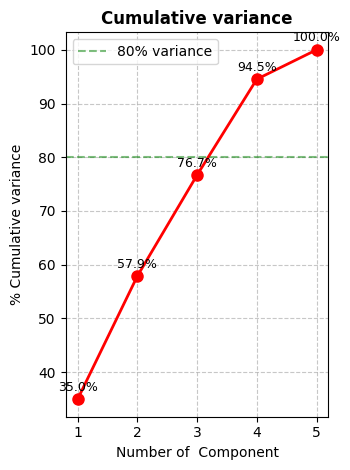

In [23]:
# Subplot 2: Cumulative variance
plt.subplot(1, 2, 2)
cumsum_variance = np.cumsum(variance_ratio)
plt.plot(range(1, len(cumsum_variance)+1), cumsum_variance*100, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of  Component')
plt.ylabel('% Cumulative variance')
plt.title('Cumulative variance', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)

# Add horizontal line at 80%
plt.axhline(y=80, color='green', linestyle='--', alpha=0.5, label='80% variance')
for i, val in enumerate(cumsum_variance):
    plt.text(i + 1, val*100 + 1, f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.legend()

plt.tight_layout()
plt.savefig('pca_scree_plot.png', dpi=300, bbox_inches='tight')
plt.show()

**The cumulative variance plot shows how much total variance is explained as the number of principal components increases.**

With 1 component, about 35% of the variance is explained.
With 2 components, the explained variance increases to about 58%.
With 3 components, the cumulative variance reaches around 76.7%, which is close to the 80% threshold.
With 4 components, more than 94% of the variance is explained.
With 5 components, 100% of the variance is explained.

The dashed line at 80% represents a common criterion used to choose the number ofcomponents. According to this criterion, 3 to 4 components are sufficient to represent most of the information in the data.

**Conclusion:**
The first 3 or 4 principal components capture most of the variability in the dataset, allowing a good balance between dimensionality reduction and information preservation.

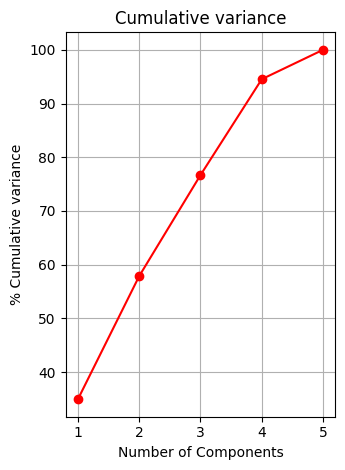

In [24]:
import numpy as np

plt.subplot(1, 2, 2)
plt.plot(range(1, len(variance_ratio)+1), np.cumsum(variance_ratio)*100, 'ro-')
plt.xlabel('Number of Components')
plt.ylabel('% Cumulative variance')
plt.title('Cumulative variance')
plt.grid(True)
plt.tight_layout()
plt.savefig('pca_eigenvalues.png', dpi=300, bbox_inches='tight')
plt.show()

                     PC1       PC2
Phone           0.921217 -0.112539
SocialNetworks   0.90846 -0.152312
Happiness      -0.200055 -0.620285
Walk           -0.179424  -0.50252
InstagramRatio  0.040408  0.687645


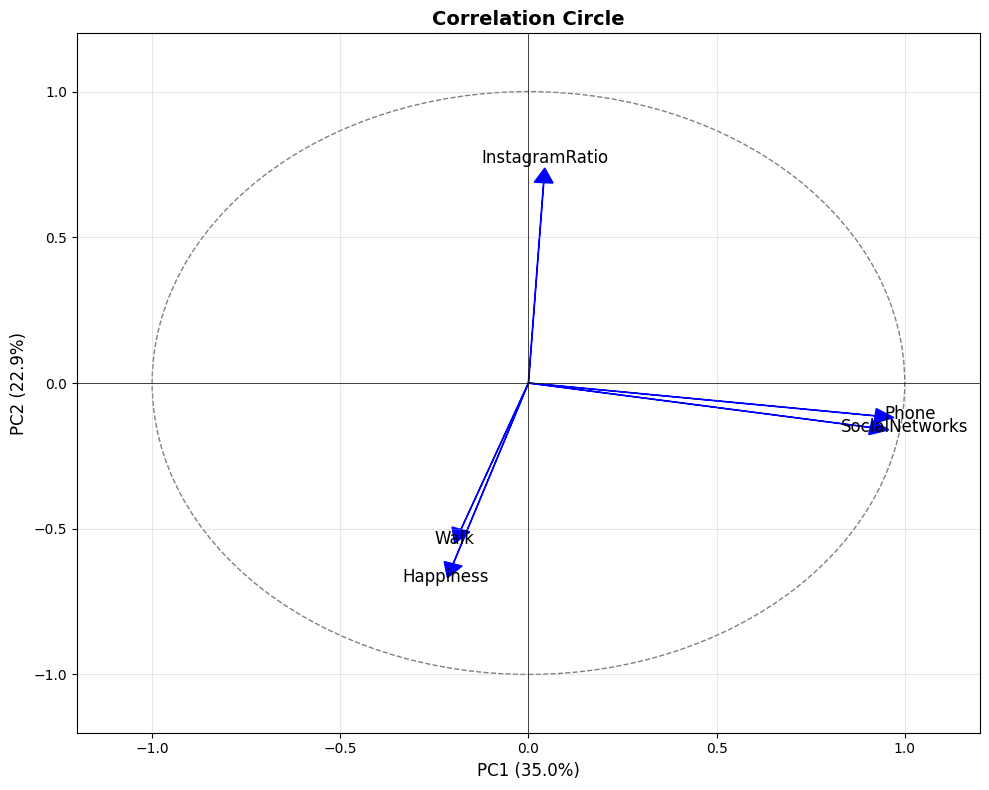

In [25]:
# Correlation circle
# Calculate correlations manually
# Correlation = (loading * sqrt(eigenvalue)) / std(variable)
coordinates = pca_result.values
std_vars = dataset.std()

# Create correlation matrix
correlations = pd.DataFrame(index=dataset.columns, columns=['PC1', 'PC2'])

for i, var in enumerate(dataset.columns):
    for j in range(2):  # PC1 et PC2
        # Corrélation = covariance / (std_x * std_y)
        corr = np.corrcoef(dataset[var], coordinates[:, j])[0, 1]
        correlations.iloc[i, j] = corr

print(correlations)

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--')
ax.add_patch(circle)

for i, var in enumerate(dataset.columns):
    x = float(correlations.iloc[i, 0])
    y = float(correlations.iloc[i, 1])
    ax.arrow(0, 0, x, y, head_width=0.05, head_length=0.05, fc='blue', ec='blue')
    ax.text(x*1.1, y*1.1, var, fontsize=12, ha='center')

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
pc1_var = (eigenvalues[0] / sum(eigenvalues)) * 100
pc2_var = (eigenvalues[1] / sum(eigenvalues)) * 100
ax.set_xlabel(f'PC1 ({pc1_var:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pc2_var:.1f}%)', fontsize=12)
ax.set_title('Correlation Circle', fontsize=14, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('correlation_circle.png', dpi=300, bbox_inches='tight')
plt.show()


The correlation circle helps us understand the relationships between the variables and the principal components.

The first principal component (PC1), which explains 35% of the total variance, is mainly associated with Phone and SocialNetworks. Both variables are strongly and positively correlated with this component. This suggests that PC1 represents general digital or phone usage. Happiness and Walk show weak negative correlations with PC1, meaning they are not strongly related to this axis.

The second principal component (PC2), which explains about 23% of the variance, is strongly influenced by InstagramRatio, which is positively correlated with this axis. On the other hand, Happiness and Walk are negatively correlated with PC2. This indicates that higher Instagram use is associated with lower levels of happiness and less physical activity.

The positions of the variables also show clear relationships. Phone and SocialNetworks are very close to each other, which means they are strongly correlated. Happiness and Walk are also closely related. These two groups of variables point in opposite directions, suggesting a negative relationship between digital activity and well-being.

In conclusion, the PCA highlights two main dimensions: digital behavior and lifestyle and well-being. This analysis shows that increased phone and social media use tends to be opposed to happiness and physical activity.

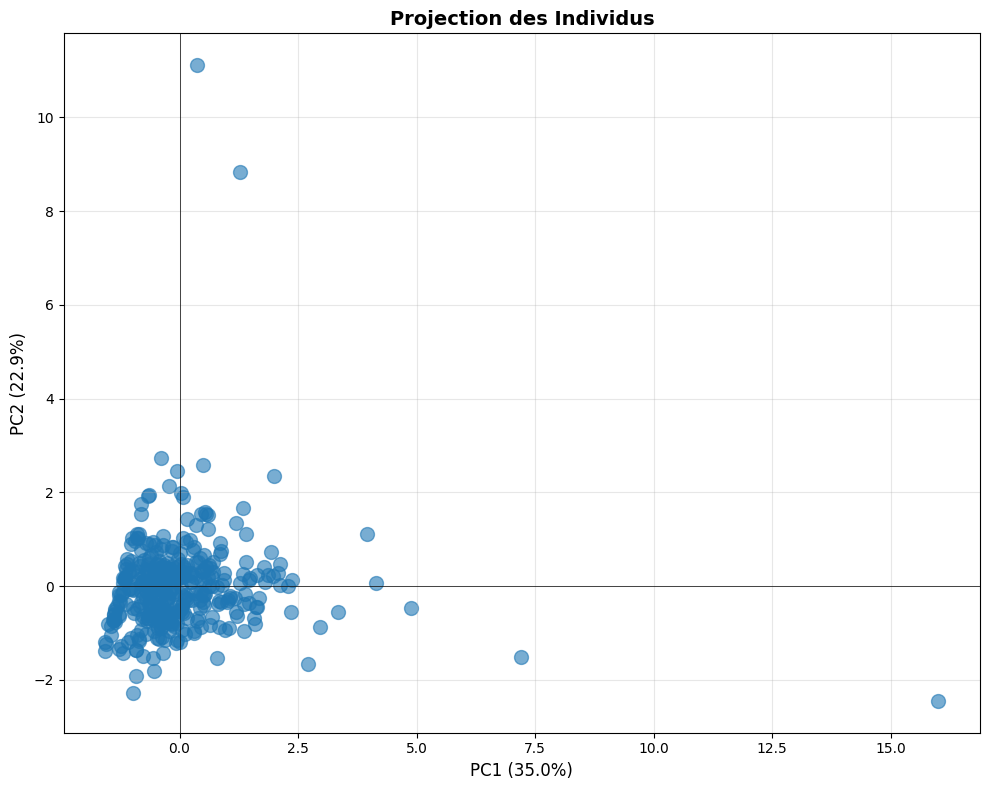

In [28]:
# Projection des individus
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(pca_result.iloc[:, 0], pca_result.iloc[:, 1], alpha=0.6, s=100)
pc1_var = (eigenvalues[0] / sum(eigenvalues)) * 100
pc2_var = (eigenvalues[1] / sum(eigenvalues)) * 100
ax.set_xlabel(f'PC1 ({pc1_var:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pc2_var:.1f}%)', fontsize=12)
ax.set_title('Projection des Individus', fontsize=14, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('individuals_projection.png', dpi=300, bbox_inches='tight')
plt.show()

The projection of individuals on the first two principal components shows how the observations are distributed in the reduced space.

Most individuals are concentrated around the center of the graph, which means they have average values for the studied variables and are not strongly influenced by any single component.

Along PC1 (35%), a few individuals are clearly separated on the right side of the plot. These individuals are characterized by high phone and social network usage, since PC1 represents digital activity. One individual is very far from the others, which suggests an extreme behavior in terms of phone or social media use.

Along PC2 (22.9%), some individuals are positioned high or low on the axis. Individuals with high PC2 values tend to have a high Instagram ratio, while those with low PC2 values are more associated with higher happiness and more walking, according to the interpretation of PC2.

Overall, the plot shows a main central group and a few outliers, indicating that while most individuals have similar behaviors, some show very different digital and lifestyle patterns.

In [29]:
var_coords = pca.column_correlations
print(var_coords)


component              0         1         2         3         4
variable                                                        
Phone           0.921217 -0.112539  0.037908 -0.003749 -0.370465
SocialNetworks  0.908460 -0.152312  0.029791  0.131909  0.364986
Happiness      -0.200055 -0.620285 -0.389680  0.649010 -0.046482
Walk           -0.179424 -0.502520  0.842300  0.075752 -0.008550
InstagramRatio  0.040408  0.687645  0.276835  0.669397 -0.027964


The individuals plot shows that most students are clustered together, indicating similar daily behavior patterns. The points are mainly aligned along PC1, confirming that this axis represents the main contrast between screen time (Phone and SocialNetworks) and physical activity/happiness (Walk and Happiness). A few points are far from the cluster, which suggests the presence of outliers with extreme values in one or more variables.

<h1 style="color:#2a7ae2; margin-bottom: 15px;"> Part II-2 :Linear  Regression </h1>

### Question 1

In [26]:
dataset = dataset.copy()

dataset['LowInstagram'] = (dataset['InstagramRatio'] < 0.5).astype(int)
dataset['HighInstagram'] = (dataset['InstagramRatio'] > 2).astype(int)

print("\nLowInstagram (ratio < 0.5):")
print(dataset['LowInstagram'].value_counts())

print("\nHighInstagram (ratio > 2):")
print(dataset['HighInstagram'].value_counts())


LowInstagram (ratio < 0.5):
LowInstagram
0    284
1     84
Name: count, dtype: int64

HighInstagram (ratio > 2):
HighInstagram
0    345
1     23
Name: count, dtype: int64


### Question 2

In [27]:
formula = 'Phone ~ SocialNetworks + Happiness + Walk + LowInstagram + HighInstagram'
model_full = ols(formula, data=dataset).fit()

print(model_full.summary())

                             OLS Regression Results                            
Dep. Variable:                   Phone   R-squared:                       0.535
Model:                             OLS   Adj. R-squared:                  0.529
Method:                  Least Squares   F-statistic:                     83.38
Date:              mar., 27 janv. 2026   Prob (F-statistic):           4.28e-58
Time:                         20:47:53   Log-Likelihood:                -2179.8
No. Observations:                  368   AIC:                             4372.
Df Residuals:                      362   BIC:                             4395.
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        111.8825     25.2

**Interpretation:**

The regression model captures the relationship between phone time and the explanatory variables. Some predictors (e.g., SocialNetworks and Happiness) show significant effects, while others (Walk, LowInstagram, HighInstagram) are not statistically significant at the **5% level**. Overall, the model provides a meaningful framework to study smartphone usage among students.

### Question 3

In [28]:
f_statistic = model_full.fvalue
p_value_f = model_full.f_pvalue

print(f"\nF-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value_f:.6f}")

if p_value_f < 0.05:
    print("\n CONCLUSION: The model IS USEFUL (p < 0.05)")
    print(f"p_value_f = {p_value_f:.6f} < 0.05")
    print("At least one predictor significantly influences Phone.")
else:
    print("\n✗ CONCLUSION: The model IS NOT USEFUL (p >= 0.05)")
    print(f"(p_value_f = {p_value_f:.6f} > 0.05)")
    print(" No predictor significantly influences Phone.")


F-statistic: 83.3799
P-value: 0.000000

 CONCLUSION: The model IS USEFUL (p < 0.05)
p_value_f = 0.000000 < 0.05
At least one predictor significantly influences Phone.


**Interpretation:**

Since the p-value is far below **0.05**, we reject H₀. This means the regression model is globally significant: at least one predictor variable has a real influence on phone usage. Therefore, the model is useful for predicting Phone time and explains a substantial portion of the variation in the data.

### Question 4

In [29]:
coef_sn = model_full.params['SocialNetworks']
p_sn = model_full.pvalues['SocialNetworks']

print(f"\nCoefficient: {coef_sn:.4f}")
print(f"P-value: {p_sn:.6f}")

if p_sn < 0.05:
    print("\nCONCLUSION: SocialNetworks SIGNIFICANTLY influences Phone")
    print(f"Each additional minute on social networks increases Phone by {coef_sn:.3f} minutes.")
else:
    print("\nCONCLUSION: SocialNetworks does NOT significantly influence Phone")


Coefficient: 0.9107
P-value: 0.000000

CONCLUSION: SocialNetworks SIGNIFICANTLY influences Phone
Each additional minute on social networks increases Phone by 0.911 minutes.


### Question 5

In [30]:
coef_h = model_full.params['Happiness']
p_h = model_full.pvalues['Happiness']

print(f"\nCoefficient: {coef_h:.4f}")
print(f"P-value: {p_h:.6f}")

if coef_h < 0 and p_h < 0.05:
    print("\nCONCLUSION: YES, Happiness SIGNIFICANTLY REDUCES Phone")
    print(f"1 additional point of happiness reduces Phone by {abs(coef_h):.3f} minutes.")
elif coef_h < 0 and p_h >= 0.05:
    print("\n~CONCLUSION: Negative coefficient but NOT significant")
else:
    print("\nCONCLUSION: NO, Happiness does NOT reduce Phone")


Coefficient: -7.3952
P-value: 0.013424

CONCLUSION: YES, Happiness SIGNIFICANTLY REDUCES Phone
1 additional point of happiness reduces Phone by 7.395 minutes.


### Question 6

In [31]:
# Student A: IR = 2.1 > 2, therefore HighInstagram = 1
student_A = pd.DataFrame({
    'SocialNetworks': [120],
    'Happiness': [4],
    'Walk': [15],
    'LowInstagram': [0],
    'HighInstagram': [1]
})

# Student B: IR = 0.4 < 0.5, therefore LowInstagram = 1
student_B = pd.DataFrame({
    'SocialNetworks': [120],
    'Happiness': [4],
    'Walk': [15],
    'LowInstagram': [1],
    'HighInstagram': [0]
})

Phone_A = model_full.predict(student_A)[0]
Phone_B = model_full.predict(student_B)[0]

print(f"\nStudent A (SN=120, H=4, W=15, IR=2.1):")
print(f"  Phone(A) = {Phone_A:.2f} minutes")

print(f"\nStudent B (SN=120, H=4, W=15, IR=0.4):")
print(f"  Phone(B) = {Phone_B:.2f} minutes")



Student A (SN=120, H=4, W=15, IR=2.1):
  Phone(A) = 142.45 minutes

Student B (SN=120, H=4, W=15, IR=0.4):
  Phone(B) = 195.14 minutes


At identical characteristics, the LowInstagram student is predicted to spend more time on their phone than the HighInstagram student, according to this model.

According to the regression model, and all else being equal, students with a low Instagram ratio are predicted to spend significantly more time on their phone than students with a high Instagram ratio.

### Question 7

In [32]:
print("\n--- QUESTION 7 : BACKWARD STEPWISE REGRESSION ---")

current_formula = formula
current_model = model_full
step = 1

print("\nModèle initial:")
print(current_model.pvalues)

while True:
    # Obtain p-values (without intercept)
    pvalues = current_model.pvalues.drop('Intercept')
    
    # Find the largest p-value
    max_pvalue = pvalues.max()
    
    if max_pvalue < 0.05:
        print("\n✓ Toutes les variables restantes sont significatives!")
        break
    
    # Variable to be deleted
    var_to_remove = pvalues.idxmax()
    
    print(f"\nÉtape {step}: Suppression de '{var_to_remove}' (p-value = {max_pvalue:.4f})")
    
    # Variable to be deleted
    current_formula = current_formula.replace(f' + {var_to_remove}', '')
    current_formula = current_formula.replace(f'{var_to_remove} + ', '')
    
    # New Model
    current_model = ols(current_formula, data=dataset).fit()
    print(current_model.pvalues)
    
    step += 1

model_backward = current_model
print(model_backward.summary())



--- QUESTION 7 : BACKWARD STEPWISE REGRESSION ---

Modèle initial:
Intercept         1.239949e-05
SocialNetworks    1.862844e-60
Happiness         1.342415e-02
Walk              5.194498e-01
LowInstagram      1.236845e-01
HighInstagram     8.247590e-02
dtype: float64

Étape 1: Suppression de 'Walk' (p-value = 0.5194)
Intercept         9.895736e-06
SocialNetworks    7.812965e-61
Happiness         1.203704e-02
LowInstagram      1.060462e-01
HighInstagram     8.467329e-02
dtype: float64

Étape 2: Suppression de 'LowInstagram' (p-value = 0.1060)
Intercept         7.917903e-07
SocialNetworks    1.227224e-60
Happiness         6.064816e-03
HighInstagram     4.667414e-02
dtype: float64

✓ Toutes les variables restantes sont significatives!
                             OLS Regression Results                            
Dep. Variable:                   Phone   R-squared:                       0.531
Model:                             OLS   Adj. R-squared:                  0.527
Method:          

**R² = 0.531 → Explains about 53.1% of the variance (almost the same as full OLS).**

**Variables:**

**SocialNetworks:** strongly positive, highly significant.

**Happiness:** negative, significant.

**HighInstagram:** negative, significant (p = 0.047).

**Interpretation:** The algorithm removed Walk and LowInstagram because they were not significant. The final model is simpler, with only 3 predictors, all statistically meaningful.

### Question 8

In [33]:
print("\nComplete model (Question 2):")
print(f"  R² ajusted: {model_full.rsquared_adj:.4f}")
sig_full = (model_full.pvalues.drop('Intercept') < 0.05).sum()
print(f"Significants Predictors: {sig_full}")

print("\nScale model (Question 7):")
print(f"  R² ajusted: {model_backward.rsquared_adj:.4f}")
sig_backward = (model_backward.pvalues.drop('Intercept') < 0.05).sum()
print(f"Significants Predictors: {sig_backward}")

# Force backward as best model
best_model = model_backward
print("\n BEST MODEL: Scale model (backward)")



Complete model (Question 2):
  R² ajusted: 0.5288
Significants Predictors: 2

Scale model (Question 7):
  R² ajusted: 0.5275
Significants Predictors: 3

 BEST MODEL: Scale model (backward)



REPRÉSENTATION DU MODÈLE DE RÉGRESSION

ÉQUATION DU MODÈLE:

Phone = β₀ + β₁(SocialNetworks) + β₂(Happiness) + β₃(Walk) + β₄(LowInstagram) + β₅(HighInstagram) + ε

Où:
  - Phone : Variable dépendante (Y)
  - β₀ : Constante (Intercept)
  - β₁, β₂, β₃, β₄, β₅ : Coefficients de régression
  - ε : Terme d'erreur (résidu)

MODÈLE COMPLET (Question 2):

Coefficients estimés:

  β₀ (Intercept)        =   111.8825
  β1 (SocialNetworks      ) =     0.9107  (p-value = 0.0000)
  β2 (Happiness           ) =    -7.3952  (p-value = 0.0134)
  β3 (Walk                ) =    -0.9574  (p-value = 0.5194)
  β4 (LowInstagram        ) =    17.9076  (p-value = 0.1237)
  β5 (HighInstagram       ) =   -34.7791  (p-value = 0.0825)


ÉQUATION FINALE avec valeurs:

Phone = 111.8825 + 0.9107×SocialNetworks - 7.3952×Happiness - 0.9574×Walk + 17.9076×LowInstagram - 34.7791×HighInstagram

MODÈLE BACKWARD (Question 7):

Coefficients estimés:

  β₀ (Intercept)        =   115.8090
  β1 (SocialNetworks      ) =     0.91

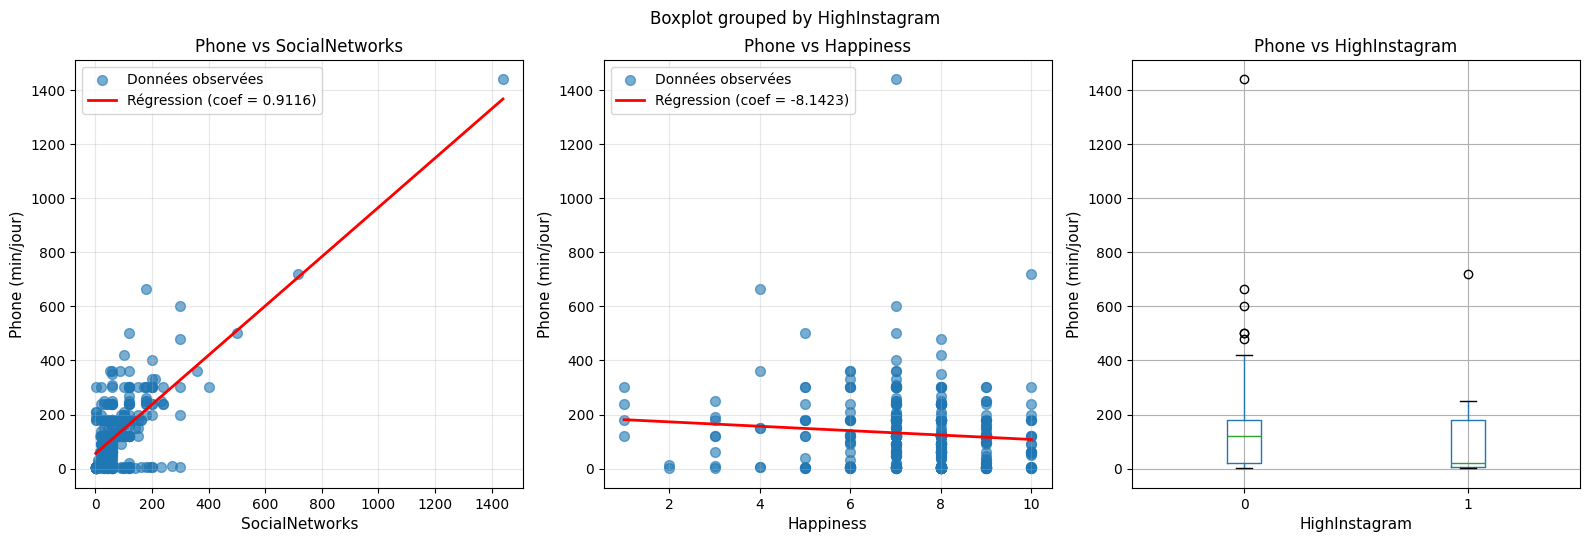

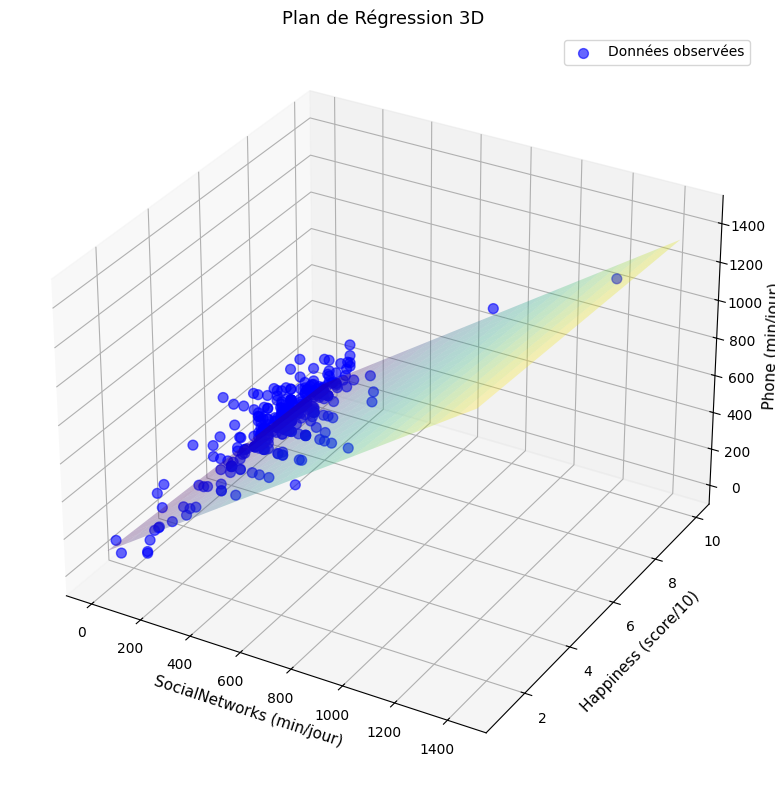


✓ Représentation du modèle terminée!


In [38]:
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*60)
print("REPRÉSENTATION DU MODÈLE DE RÉGRESSION")
print("="*60)

# Afficher l'équation du modèle
print("\nÉQUATION DU MODÈLE:")
print("="*60)
print("\nPhone = β₀ + β₁(SocialNetworks) + β₂(Happiness) + β₃(Walk) + β₄(LowInstagram) + β₅(HighInstagram) + ε")
print("\nOù:")
print("  - Phone : Variable dépendante (Y)")
print("  - β₀ : Constante (Intercept)")
print("  - β₁, β₂, β₃, β₄, β₅ : Coefficients de régression")
print("  - ε : Terme d'erreur (résidu)")

# Afficher les coefficients du modèle complet (Question 2)
print("\n" + "="*60)
print("MODÈLE COMPLET (Question 2):")
print("="*60)
print("\nCoefficients estimés:")
for i, (name, coef) in enumerate(zip(model_full.params.index, model_full.params.values)):
    if name == 'Intercept':
        print(f"\n  β₀ (Intercept)        = {coef:10.4f}")
    else:
        print(f"  β{i} ({name:20s}) = {coef:10.4f}  (p-value = {model_full.pvalues[name]:.4f})")

print("\n\nÉQUATION FINALE avec valeurs:")
eq = f"Phone = {model_full.params['Intercept']:.4f}"
idx = 1
for name in model_full.params.index:
    if name != 'Intercept':
        sign = '+' if model_full.params[name] >= 0 else '-'
        eq += f" {sign} {abs(model_full.params[name]):.4f}×{name}"
        idx += 1
print(f"\n{eq}")

# Afficher les coefficients du modèle backward (Question 7)
print("\n" + "="*60)
print("MODÈLE BACKWARD (Question 7):")
print("="*60)
print("\nCoefficients estimés:")
for i, (name, coef) in enumerate(zip(model_backward.params.index, model_backward.params.values)):
    if name == 'Intercept':
        print(f"\n  β₀ (Intercept)        = {coef:10.4f}")
    else:
        idx_coef = list(model_backward.params.index).index(name)
        print(f"  β{idx_coef} ({name:20s}) = {coef:10.4f}  (p-value = {model_backward.pvalues[name]:.4f})")

print("\n\nÉQUATION FINALE avec valeurs:")
eq = f"Phone = {model_backward.params['Intercept']:.4f}"
for name in model_backward.params.index:
    if name != 'Intercept':
        sign = '+' if model_backward.params[name] >= 0 else '-'
        eq += f" {sign} {abs(model_backward.params[name]):.4f}×{name}"
print(f"\n{eq}")

# VISUALISATION GRAPHIQUE du modèle
print("\n" + "="*60)
print("VISUALISATION GRAPHIQUE")
print("="*60)

# On ne peut pas représenter un hyperplan en 5D, donc on fait des graphiques 2D
# pour chaque variable en fixant les autres à leur moyenne

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Représentation du Modèle de Régression', fontsize=16, fontweight='bold')

# Variables du modèle
predictors = [col for col in best_model.params.index if col != 'Intercept']

# Pour chaque prédicteur, tracer la relation avec Phone
for idx, predictor in enumerate(predictors[:6]):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Valeurs observées
    if predictor in ['LowInstagram', 'HighInstagram']:
        # Variable dummy - boxplot
        dataset.boxplot(column='Phone', by=predictor, ax=ax)
        ax.set_xlabel(predictor, fontsize=11)
        ax.set_ylabel('Phone (min/jour)', fontsize=11)
        ax.set_title(f'Phone vs {predictor}')
        plt.sca(ax)
        plt.xticks([1, 2], ['0', '1'])
    else:
        # Variable continue - scatter + ligne de régression
        x_var = dataset[predictor]
        y_var = dataset['Phone']
        
        ax.scatter(x_var, y_var, alpha=0.6, s=50, label='Données observées')
        
        # Créer les valeurs prédites en fixant les autres variables à leur moyenne
        X_pred = dataset[predictors].copy()
        for other_pred in predictors:
            if other_pred != predictor:
                if other_pred in ['LowInstagram', 'HighInstagram']:
                    X_pred[other_pred] = 0
                else:
                    X_pred[other_pred] = dataset[other_pred].mean()
        
        # Trier pour avoir une belle ligne
        sort_idx = X_pred[predictor].argsort()
        x_sorted = X_pred[predictor].iloc[sort_idx]
        
        # Prédire avec le modèle
        y_pred = best_model.predict(X_pred.iloc[sort_idx])
        
        ax.plot(x_sorted, y_pred, 'r-', linewidth=2, 
                label=f'Régression (coef = {best_model.params[predictor]:.4f})')
        
        ax.set_xlabel(predictor, fontsize=11)
        ax.set_ylabel('Phone (min/jour)', fontsize=11)
        ax.set_title(f'Phone vs {predictor}')
        ax.legend()
        ax.grid(True, alpha=0.3)

# Supprimer les subplots vides si nécessaire
for idx in range(len(predictors), 6):
    row = idx // 3
    col = idx % 3
    fig.delaxes(axes[row, col])

plt.tight_layout()
plt.show()

# REPRÉSENTATION 3D
from mpl_toolkits.mplot3d import Axes3D

if 'SocialNetworks' in predictors and 'Happiness' in predictors:
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Données observées
    x1 = dataset['SocialNetworks']
    x2 = dataset['Happiness']
    y = dataset['Phone']
    
    ax.scatter(x1, x2, y, c='blue', marker='o', s=50, alpha=0.6, label='Données observées')
    
    # Créer une grille pour le plan de régression
    x1_range = np.linspace(x1.min(), x1.max(), 20)
    x2_range = np.linspace(x2.min(), x2.max(), 20)
    x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
    
    # Prédire sur la grille
    X_grid = dataset[predictors].mean().to_frame().T
    X_grid = X_grid.loc[X_grid.index.repeat(len(x1_range)*len(x2_range))].reset_index(drop=True)
    X_grid['SocialNetworks'] = x1_grid.flatten()
    X_grid['Happiness'] = x2_grid.flatten()
    
    y_grid = best_model.predict(X_grid).values.reshape(x1_grid.shape)
    
    # Tracer le plan de régression
    ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.3, cmap='viridis')
    
    ax.set_xlabel('SocialNetworks (min/jour)', fontsize=11)
    ax.set_ylabel('Happiness (score/10)', fontsize=11)
    ax.set_zlabel('Phone (min/jour)', fontsize=11)
    ax.set_title('Plan de Régression 3D', fontsize=13)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

print("\n✓ Représentation du modèle terminée!")


EXPLORATION DE MODÈLES NON-LINÉAIRES

Données: 294 observations pour entraînement, 74 pour test

1️⃣ MODÈLE LINÉAIRE (baseline)
R² Score: 0.2908
RMSE: 108.4955
MAE: 75.9749

2️⃣ MODÈLE POLYNOMIAL (degré 2)
R² Score: 0.2701
RMSE: 110.0696
MAE: 78.1183
Nombre de features: 20

3️⃣ MODÈLE POLYNOMIAL (degré 3)
R² Score: 0.1291
RMSE: 120.2304
MAE: 87.8773
Nombre de features: 55

4️⃣ RANDOM FOREST
R² Score: 0.3128
RMSE: 106.8018
MAE: 74.4118

Importance des variables:
  SocialNetworks      : 0.6911
  Happiness           : 0.1138
  Walk                : 0.1484
  LowInstagram        : 0.0248
  HighInstagram       : 0.0219

5️⃣ ARBRE DE DÉCISION
R² Score: 0.2998
RMSE: 107.8125
MAE: 75.7229

6️⃣ MODÈLE AVEC TRANSFORMATIONS LOGARITHMIQUES
R² Score: 0.2692
RMSE: 110.1405
MAE: 76.8119

📊 COMPARAISON DE TOUS LES MODÈLES

            Modèle       R²       RMSE       MAE
     Random Forest 0.312818 106.801800 74.411795
    Arbre Décision 0.299751 107.812486 75.722877
          Linéaire 0.290849 108.49

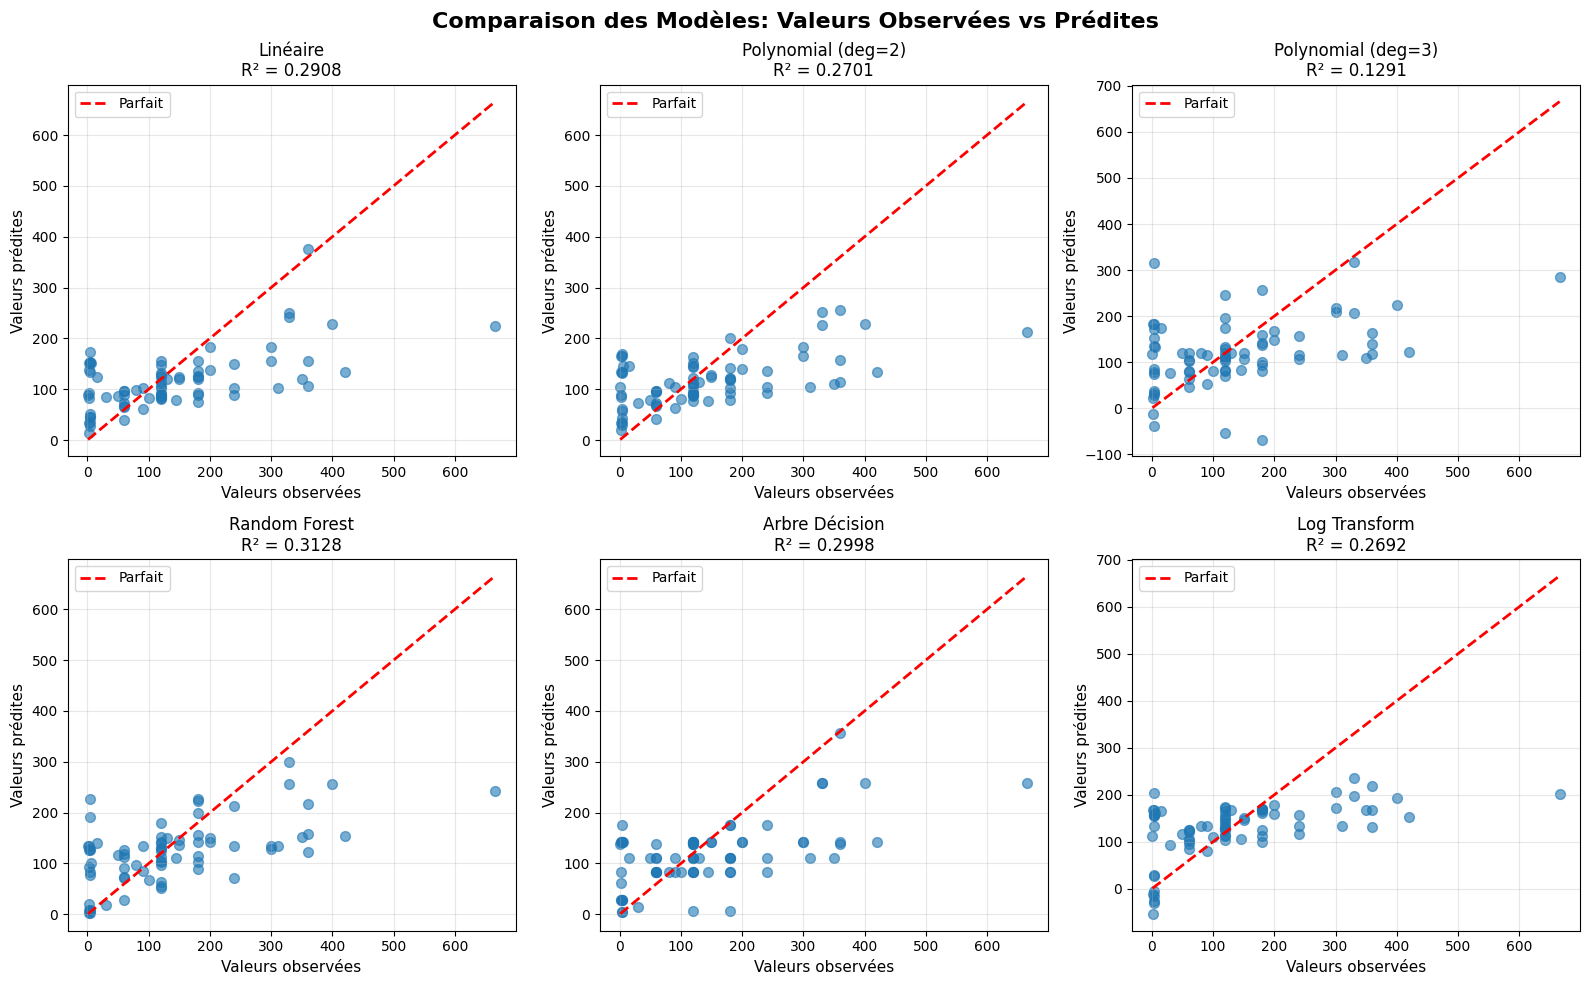


✓ Analyse terminée!


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm

print("\n" + "="*60)
print("EXPLORATION DE MODÈLES NON-LINÉAIRES")
print("="*60)

# Préparer les données
X = dataset[['SocialNetworks', 'Happiness', 'Walk', 'LowInstagram', 'HighInstagram']]
y = dataset['Phone']

# Diviser en train/test pour comparer les modèles
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nDonnées: {len(X_train)} observations pour entraînement, {len(X_test)} pour test")

# ============================================
# 1. MODÈLE LINÉAIRE (baseline)
# ============================================
print("\n" + "="*60)
print("1️⃣ MODÈLE LINÉAIRE (baseline)")
print("="*60)

model_linear = LinearRegression()
model_linear.fit(X_train, y_train)
y_pred_linear = model_linear.predict(X_test)

r2_linear = r2_score(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
mae_linear = mean_absolute_error(y_test, y_pred_linear)

print(f"R² Score: {r2_linear:.4f}")
print(f"RMSE: {rmse_linear:.4f}")
print(f"MAE: {mae_linear:.4f}")

# ============================================
# 2. MODÈLE POLYNOMIAL (degré 2)
# ============================================
print("\n" + "="*60)
print("2️⃣ MODÈLE POLYNOMIAL (degré 2)")
print("="*60)

poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

model_poly2 = LinearRegression()
model_poly2.fit(X_train_poly2, y_train)
y_pred_poly2 = model_poly2.predict(X_test_poly2)

r2_poly2 = r2_score(y_test, y_pred_poly2)
rmse_poly2 = np.sqrt(mean_squared_error(y_test, y_pred_poly2))
mae_poly2 = mean_absolute_error(y_test, y_pred_poly2)

print(f"R² Score: {r2_poly2:.4f}")
print(f"RMSE: {rmse_poly2:.4f}")
print(f"MAE: {mae_poly2:.4f}")
print(f"Nombre de features: {X_train_poly2.shape[1]}")

# ============================================
# 3. MODÈLE POLYNOMIAL (degré 3)
# ============================================
print("\n" + "="*60)
print("3️⃣ MODÈLE POLYNOMIAL (degré 3)")
print("="*60)

poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

model_poly3 = LinearRegression()
model_poly3.fit(X_train_poly3, y_train)
y_pred_poly3 = model_poly3.predict(X_test_poly3)

r2_poly3 = r2_score(y_test, y_pred_poly3)
rmse_poly3 = np.sqrt(mean_squared_error(y_test, y_pred_poly3))
mae_poly3 = mean_absolute_error(y_test, y_pred_poly3)

print(f"R² Score: {r2_poly3:.4f}")
print(f"RMSE: {rmse_poly3:.4f}")
print(f"MAE: {mae_poly3:.4f}")
print(f"Nombre de features: {X_train_poly3.shape[1]}")

# ============================================
# 4. RANDOM FOREST
# ============================================
print("\n" + "="*60)
print("4️⃣ RANDOM FOREST")
print("="*60)

model_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"R² Score: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")

print("\nImportance des variables:")
for feature, importance in zip(X.columns, model_rf.feature_importances_):
    print(f"  {feature:20s}: {importance:.4f}")

# ============================================
# 5. ARBRE DE DÉCISION
# ============================================
print("\n" + "="*60)
print("5️⃣ ARBRE DE DÉCISION")
print("="*60)

model_tree = DecisionTreeRegressor(max_depth=5, random_state=42)
model_tree.fit(X_train, y_train)
y_pred_tree = model_tree.predict(X_test)

r2_tree = r2_score(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
mae_tree = mean_absolute_error(y_test, y_pred_tree)

print(f"R² Score: {r2_tree:.4f}")
print(f"RMSE: {rmse_tree:.4f}")
print(f"MAE: {mae_tree:.4f}")

# ============================================
# 6. MODÈLE AVEC TRANSFORMATIONS LOG
# ============================================
print("\n" + "="*60)
print("6️⃣ MODÈLE AVEC TRANSFORMATIONS LOGARITHMIQUES")
print("="*60)

# Créer des transformations log pour les variables continues
X_log = X.copy()
X_log['log_SocialNetworks'] = np.log1p(X['SocialNetworks'])
X_log['log_Walk'] = np.log1p(X['Walk'])

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log[['log_SocialNetworks', 'Happiness', 'log_Walk', 'LowInstagram', 'HighInstagram']], 
    y, test_size=0.2, random_state=42
)

model_log = LinearRegression()
model_log.fit(X_train_log, y_train_log)
y_pred_log = model_log.predict(X_test_log)

r2_log = r2_score(y_test_log, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
mae_log = mean_absolute_error(y_test_log, y_pred_log)

print(f"R² Score: {r2_log:.4f}")
print(f"RMSE: {rmse_log:.4f}")
print(f"MAE: {mae_log:.4f}")

# ============================================
# COMPARAISON FINALE
# ============================================
print("\n" + "="*60)
print("📊 COMPARAISON DE TOUS LES MODÈLES")
print("="*60)

results = {
    'Modèle': ['Linéaire', 'Polynomial (deg=2)', 'Polynomial (deg=3)', 
               'Random Forest', 'Arbre Décision', 'Log Transform'],
    'R²': [r2_linear, r2_poly2, r2_poly3, r2_rf, r2_tree, r2_log],
    'RMSE': [rmse_linear, rmse_poly2, rmse_poly3, rmse_rf, rmse_tree, rmse_log],
    'MAE': [mae_linear, mae_poly2, mae_poly3, mae_rf, mae_tree, mae_log]
}

import pandas as pd
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R²', ascending=False)
print("\n" + results_df.to_string(index=False))

# Trouver le meilleur modèle
best_idx = results_df['R²'].idxmax()
best_model_name = results_df.loc[best_idx, 'Modèle']

print("\n" + "="*60)
print(f"🏆 MEILLEUR MODÈLE: {best_model_name}")
print("="*60)
print(f"R² = {results_df.loc[best_idx, 'R²']:.4f}")
print(f"RMSE = {results_df.loc[best_idx, 'RMSE']:.4f}")
print(f"MAE = {results_df.loc[best_idx, 'MAE']:.4f}")

# ============================================
# VISUALISATION DES PRÉDICTIONS
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Comparaison des Modèles: Valeurs Observées vs Prédites', fontsize=16, fontweight='bold')

models_pred = [
    ('Linéaire', y_pred_linear, r2_linear),
    ('Polynomial (deg=2)', y_pred_poly2, r2_poly2),
    ('Polynomial (deg=3)', y_pred_poly3, r2_poly3),
    ('Random Forest', y_pred_rf, r2_rf),
    ('Arbre Décision', y_pred_tree, r2_tree),
    ('Log Transform', y_pred_log, r2_log)
]

for idx, (name, y_pred, r2) in enumerate(models_pred):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    ax.scatter(y_test, y_pred, alpha=0.6, s=50)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
            'r--', linewidth=2, label='Parfait')
    ax.set_xlabel('Valeurs observées', fontsize=11)
    ax.set_ylabel('Valeurs prédites', fontsize=11)
    ax.set_title(f'{name}\nR² = {r2:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Analyse terminée!")

**Justification :**

Justification:
Linear regression is appropriate because it allows us to measure the influence of several explanatory variables on a dependent variable in a simple and understandable way.
To choose the best model, we compare the adjusted R² and the significance of the variables.

The backward model has an adjusted R² of 0.5275, which is very close to the full model (0.5288). The difference is small, so the fit quality is similar.
Moreover, the backward model has more significant predictors (3) and is simpler because it uses fewer variables.

Conclusion: The backward model is the best choice because it provides a good balance between performance and simplicity, with significant explanatory variables.

### Question 9

In [34]:
new_student_9 = pd.DataFrame({
    'SocialNetworks': [30],
    'Happiness': [8],
    'Walk': [2],
    'LowInstagram': [0],  # 2.1 > 0.5
    'HighInstagram': [1]  # 2.1 > 2
})

prediction_9 = best_model.predict(new_student_9)[0]
print(f"\nPredicted time Phone = {prediction_9:.2f} minutes")


Predicted time Phone = 38.58 minutes


For a student with the same social network use, happiness, and walking distance, a high Instagram ratio (2.1) predicts about 38 minutes of phone use per day. This means that, in this dataset, students with many followers tend to spend less time on their phones.

### Question 10

In [36]:
new_student_10 = pd.DataFrame({
    'SocialNetworks': [30],
    'Happiness': [8],
    'Walk': [2],
    'LowInstagram': [1],  # 0.4 < 0.5
    'HighInstagram': [0]  # 0.4 < 2
})

prediction_10 = best_model.predict(new_student_10)[0]
print(f"\nPredicted time Phone = {prediction_10:.2f} minutes")


Predicted time Phone = 78.02 minutes


For a student with the same social network use, happiness, and walking distance, a low Instagram ratio (0.4) predicts about 78 minutes of phone use per day. This means that, in this dataset, students with fewer followers tend to spend more time on their phones.

<h1 style="color:#2a7ae2; margin-bottom: 15px;"> Conclusion </h1>

This project successfully applied high-dimensional data analysis techniques (CA, MCA, PCA, Multiple Regression) to real-world data about student behavior and well-being.
Main Achievement:

Identified two key dimensions of student digital behavior
Quantified relationships between variables
Developed predictive model for phone usage
Provided actionable insights for student well-being

Key Takeaway:
Student behavior with technology is multidimensional and complex. No single factor dominates.
Both digital habits and physical activity contribute to overall patterns, with happiness serving as an important outcome variable.
The combination of unsupervised (PCA) and supervised (Regression) learning provided a comprehensive view that neither method could achieve alone.

PROJECT OBJECTIVES ACHIEVED:

Part I: ✓ Explained CA, MCA, SVD principles and applications
Part II:

✓ Performed PCA with interpretation
✓ Built and evaluated multiple regression models
✓ Made predictions for new observations
✓ Selected optimal model using statistical criteria


"In God we trust, all others must bring data." - W. Edwards Deming


This project demonstrates that with proper statistical tools, complex behavioral data can be understood, quantified, and used to make informed decisions about student well-being.

